In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", message=r"invalid value encountered in log10", category=RuntimeWarning, module=r".*specparam.*")

from specparam import Bands
from spk_feat_cluster_analysis import *
from spe1_plotting import *
from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT, LFP_FS


In [3]:
cell_num = 26

lfp_fs   = LFP_FS                    # from config
patch_fs = DICT_PATCH_FS[cell_num]

FORCE_LFP    = False  # True → reextract LFP windows even if pickle exists
FORCE_SIMPLE = False  # True → recompute simple LFP features even if pickle exists
FORCE_STATS  = False  # True → rerun sliding-window stats even if pickle exists


In [5]:
# Load pre-processed .npy recordings
lfp_dir   = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings',  f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')

lfp_filt   = np.load(lfp_dir)
patch_filt = np.load(patch_dir)

lfp_times   = np.arange(len(lfp_filt))   / (lfp_fs   / 1000.0)  # ms
patch_times = np.arange(len(patch_filt)) / (patch_fs  / 1000.0)  # ms


In [6]:
# Load cluster DataFrame from pickle (run spe-1_c{cell_num}_clusters.ipynb first)
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')
with open(cluster_pickle, 'rb') as f:
    df_features_clust = pickle.load(f)
print(f"Loaded {len(df_features_clust)} spikes with columns: {[c for c in df_features_clust.columns if '_cluster' in c]}")


Loaded 5824 spikes with columns: ['log_isi_cluster']


In [7]:
# Load or extract LFP windows around each spike
lfp_win_pickle = os.path.join(SPE1_PICKLE_ROOT, 'lfp_window_pickles', f'c{cell_num}_lfp_windows.pkl')

if FORCE_LFP or not os.path.exists(lfp_win_pickle):
    all_spike_extractor = extract_lfp_windows(
        spk_df=df_features_clust,
        lfp_times_ms=lfp_times,
        lfp_signal=lfp_filt,
        pre_s=1.0, post_s=1.5,
        condition=None,
    )
    with open(lfp_win_pickle, 'wb') as f:
        pickle.dump(all_spike_extractor, f)
    print(f"  Saved: {os.path.basename(lfp_win_pickle)}")
else:
    print(f"  [cache] {os.path.basename(lfp_win_pickle)}")
    with open(lfp_win_pickle, 'rb') as f:
        all_spike_extractor = pickle.load(f)

windows_all     = all_spike_extractor["windows"]
t_rel_all       = all_spike_extractor["times_rel_ms"]
next_spk_all    = all_spike_extractor["next_spike_times_ms"]


  Saved: c26_lfp_windows.pkl


In [ ]:
# Compute or load per-spike time-resolved specparam
import re, math
chunk_dir    = os.path.join(SPE1_PICKLE_ROOT, "multitaper_pickles", f"c{cell_num}")
chunk_prefix = f"c{cell_num}_specparam"
os.makedirs(chunk_dir, exist_ok=True)
existing_chunks = sorted(
    [f for f in os.listdir(chunk_dir) if f.startswith(chunk_prefix) and f.endswith(".pkl")],
    key=lambda f: int(re.search(r'_(\d+)\.pkl$', f).group(1))
)
n_total_chunks = math.ceil(len(windows_all) / 200)

if FORCE_LFP or len(existing_chunks) == 0:
    resume = 0
elif len(existing_chunks) < n_total_chunks:
    saved_idxs = [int(re.search(r'_(\d+)\.pkl$', f).group(1)) for f in existing_chunks]
    resume = max(saved_idxs) + 1
    print(f"  Resuming from chunk {resume}/{n_total_chunks - 1} ({len(existing_chunks)} already done)")
else:
    resume = None

if resume is not None:
    print(f"  Computing specparam for {len(windows_all)} spikes (chunked)...")
    specparam_by_spike = run_time_resolved_specparam_per_spike(
        lfp_windows        = windows_all,
        times_rel_list     = t_rel_all,
        next_rel_list      = next_spk_all,
        fs                 = lfp_fs,
        chunk_size         = 200,
        save_dir           = chunk_dir,
        save_prefix        = chunk_prefix,
        resume_start_chunk = resume,
        decim_factor       = 100,
        n_freqs            = 50,
    )
else:
    print(f"  [cache] {len(existing_chunks)}/{n_total_chunks} chunks — loading...")
    specparam_by_spike = load_chunked_specparam_results(save_dir=chunk_dir, prefix=chunk_prefix)

specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)
print(f"Specparam ready for {len(specparam_by_spike)} spikes")


In [9]:
groups = build_lfp_groups_from_clusters(df_features_clust, all_spike_extractor)
print(f"Groups: {list(groups.keys())}")


Groups: ['log_isi_cluster: low', 'log_isi_cluster: high']


In [10]:
# Compute (or load) simple LFP features per spike window
simple_pickle = os.path.join(SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl')

if FORCE_SIMPLE or not os.path.exists(simple_pickle):
    lfp_windows_by_spike = compute_simple_lfp_by_spike(
        windows_all=windows_all,
        times_rel_list=t_rel_all,
        fs=lfp_fs,
        inner_window_s=0.5,
        step_s=0.025,
        freq_range=(4, 90),
    )
    with open(simple_pickle, 'wb') as f:
        pickle.dump(lfp_windows_by_spike, f)
    print(f"  Saved: {os.path.basename(simple_pickle)}")
else:
    print(f"  [cache] {os.path.basename(simple_pickle)}")
    with open(simple_pickle, 'rb') as f:
        lfp_windows_by_spike = pickle.load(f)


  Saved: c26_simple_lfp.pkl


## Run sliding-window LFP-spike group analysis


  RUNNING PIPELINE FOR: APERIODIC EXPONENT


  RUNNING PIPELINE FOR: APERIODIC OFFSET


  RUNNING PIPELINE FOR: THETA AUC


  RUNNING PIPELINE FOR: BETA AUC


  RUNNING PIPELINE FOR: GAMMA AUC


  RUNNING PIPELINE FOR: R-SQUARED


  RUNNING PIPELINE FOR: LFP MEAN AMPLITUDE



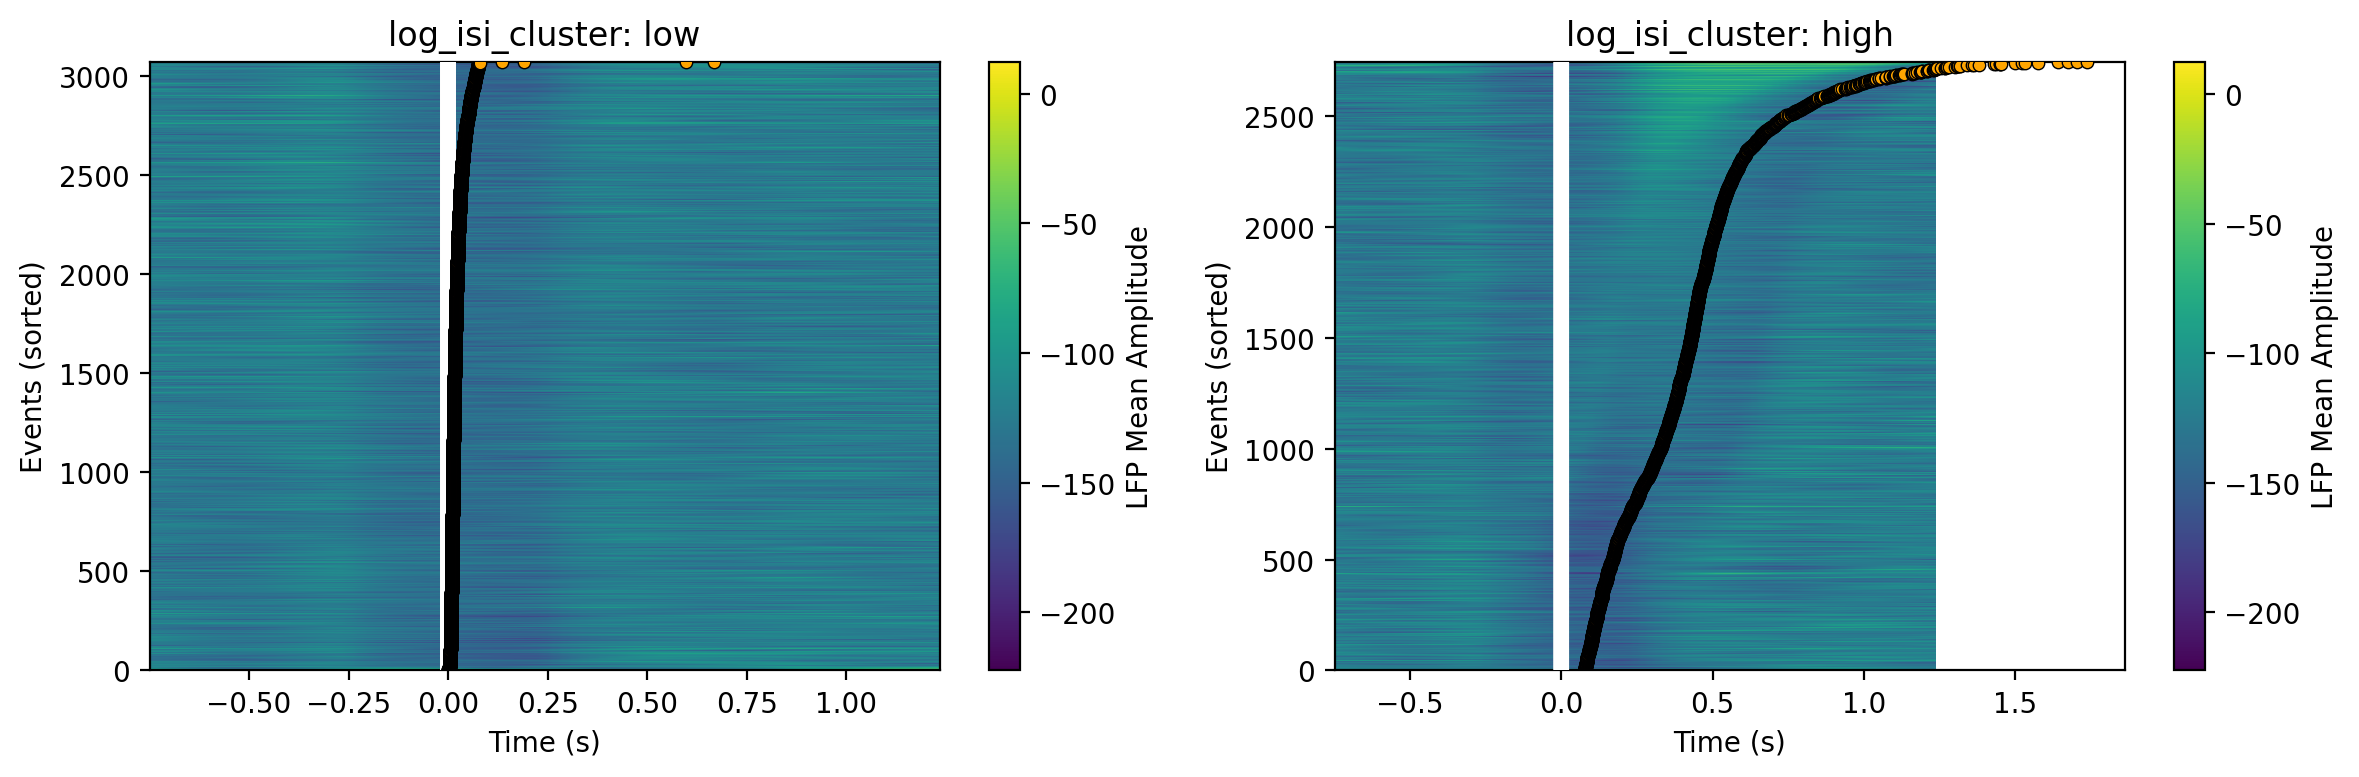

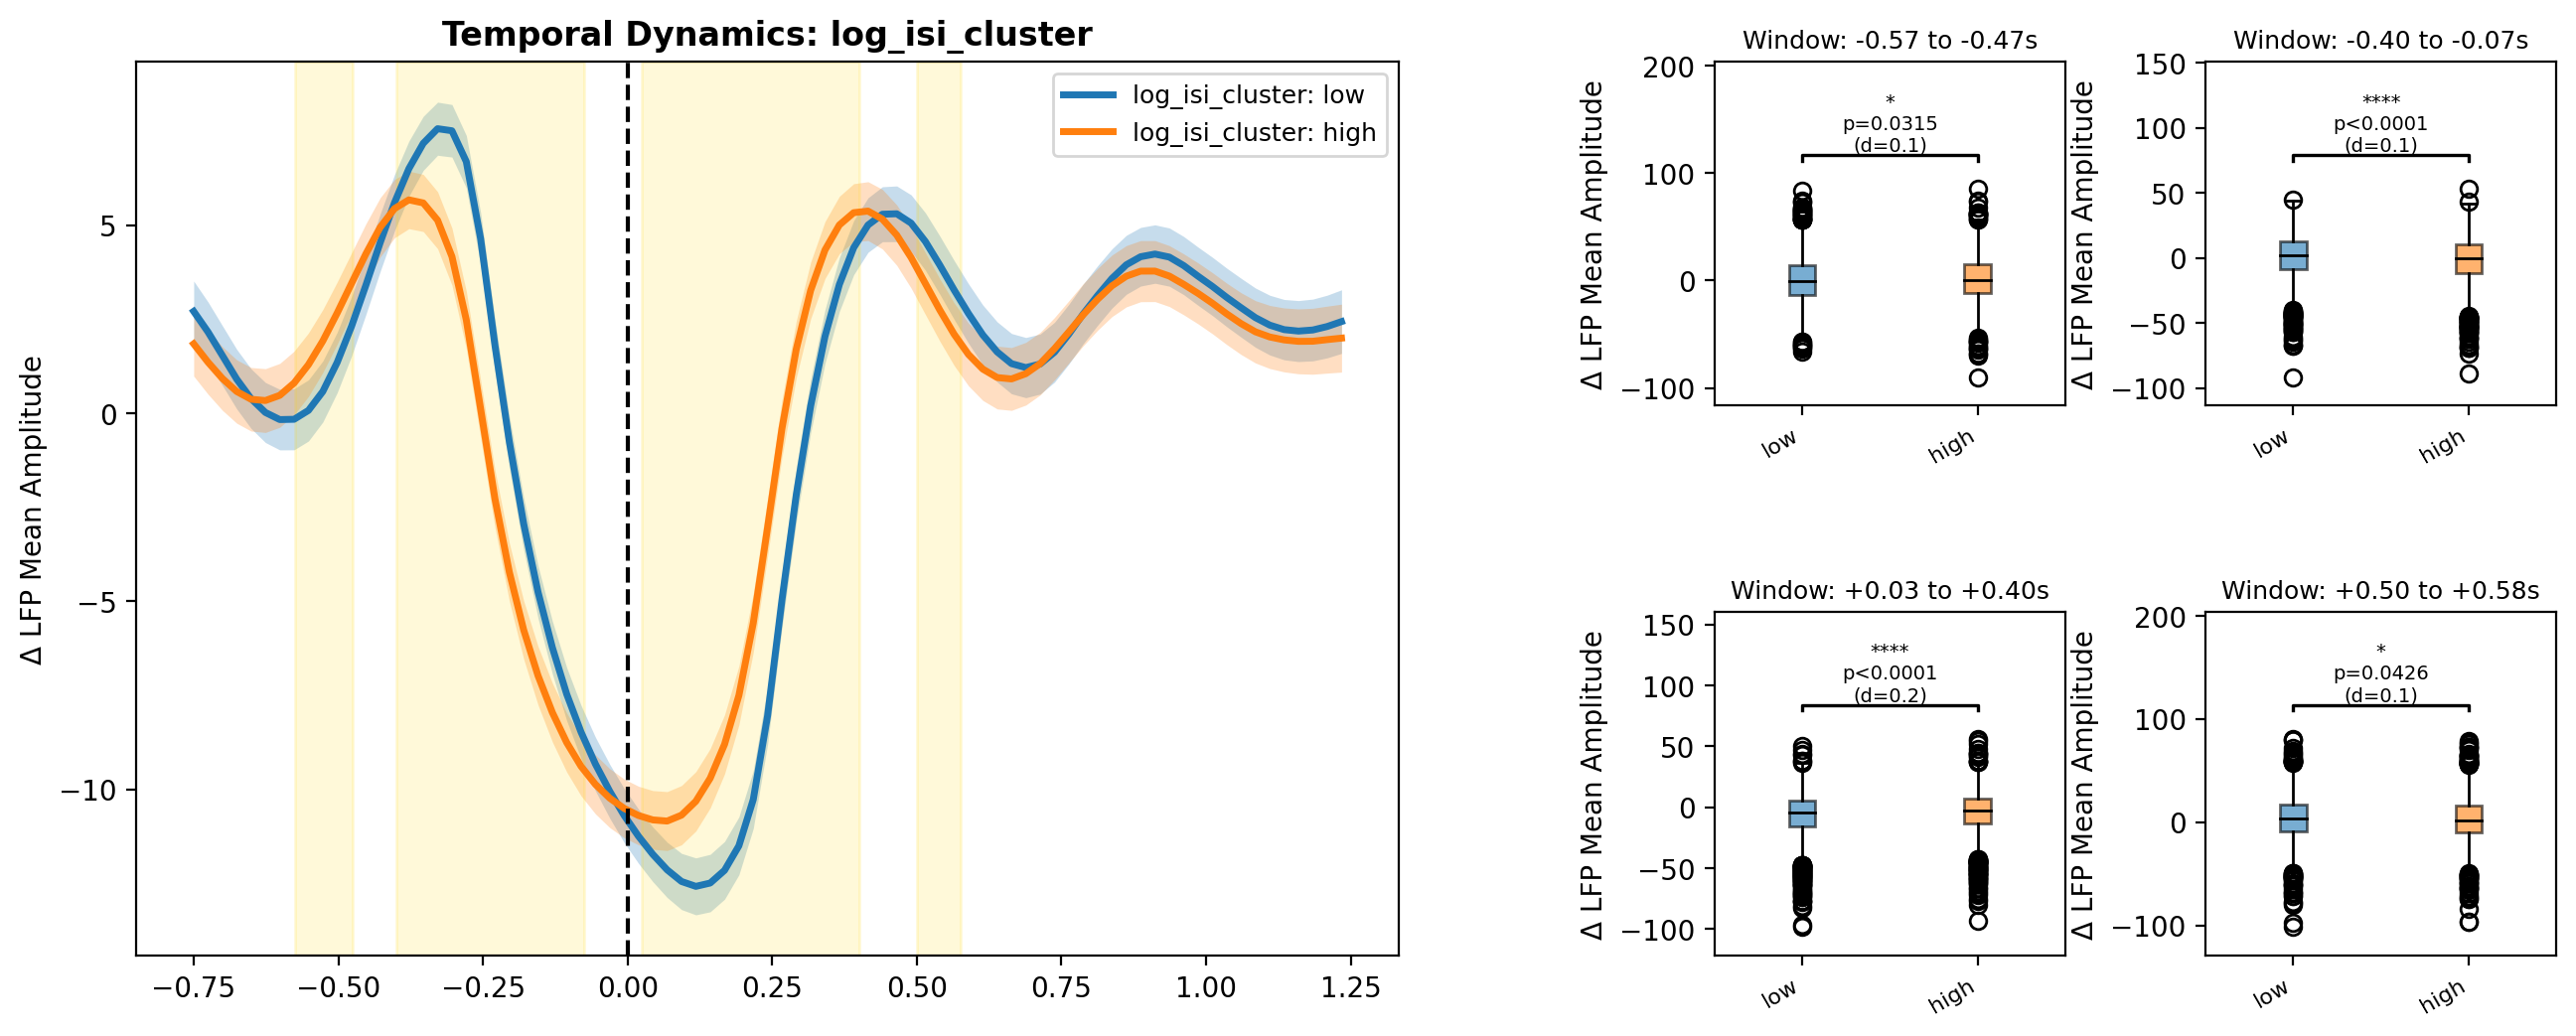


  RUNNING PIPELINE FOR: LFP STD



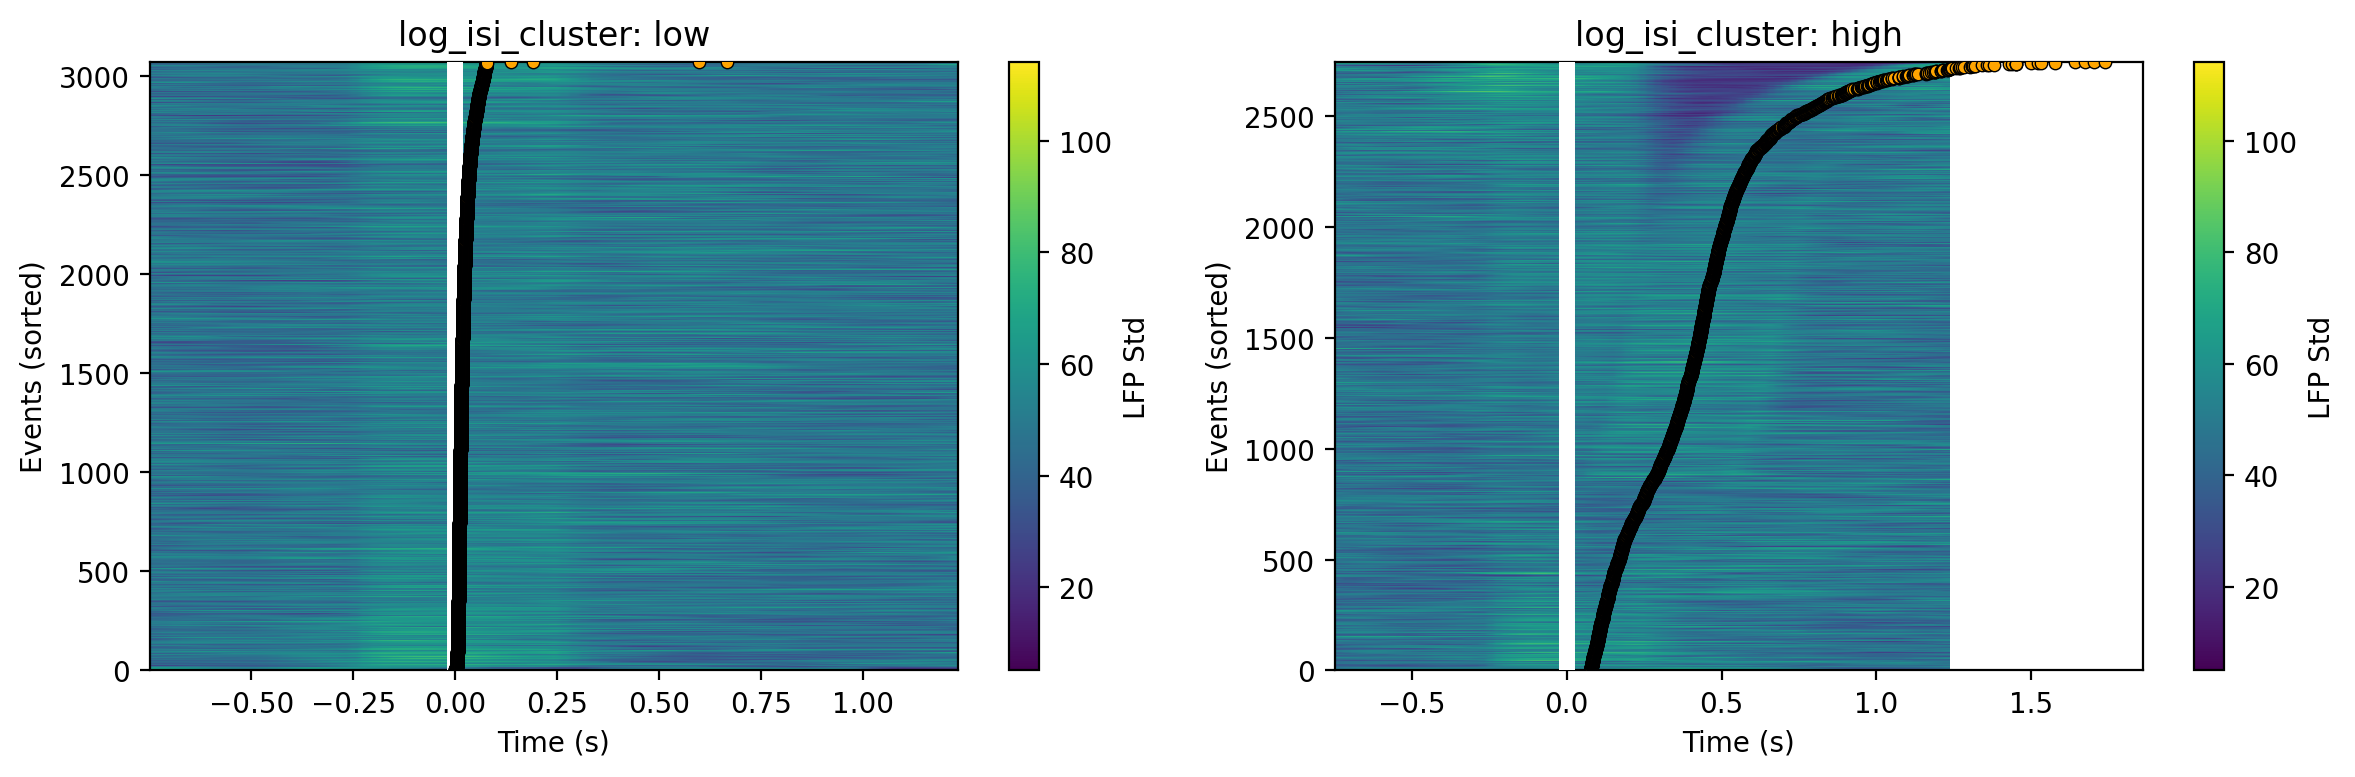

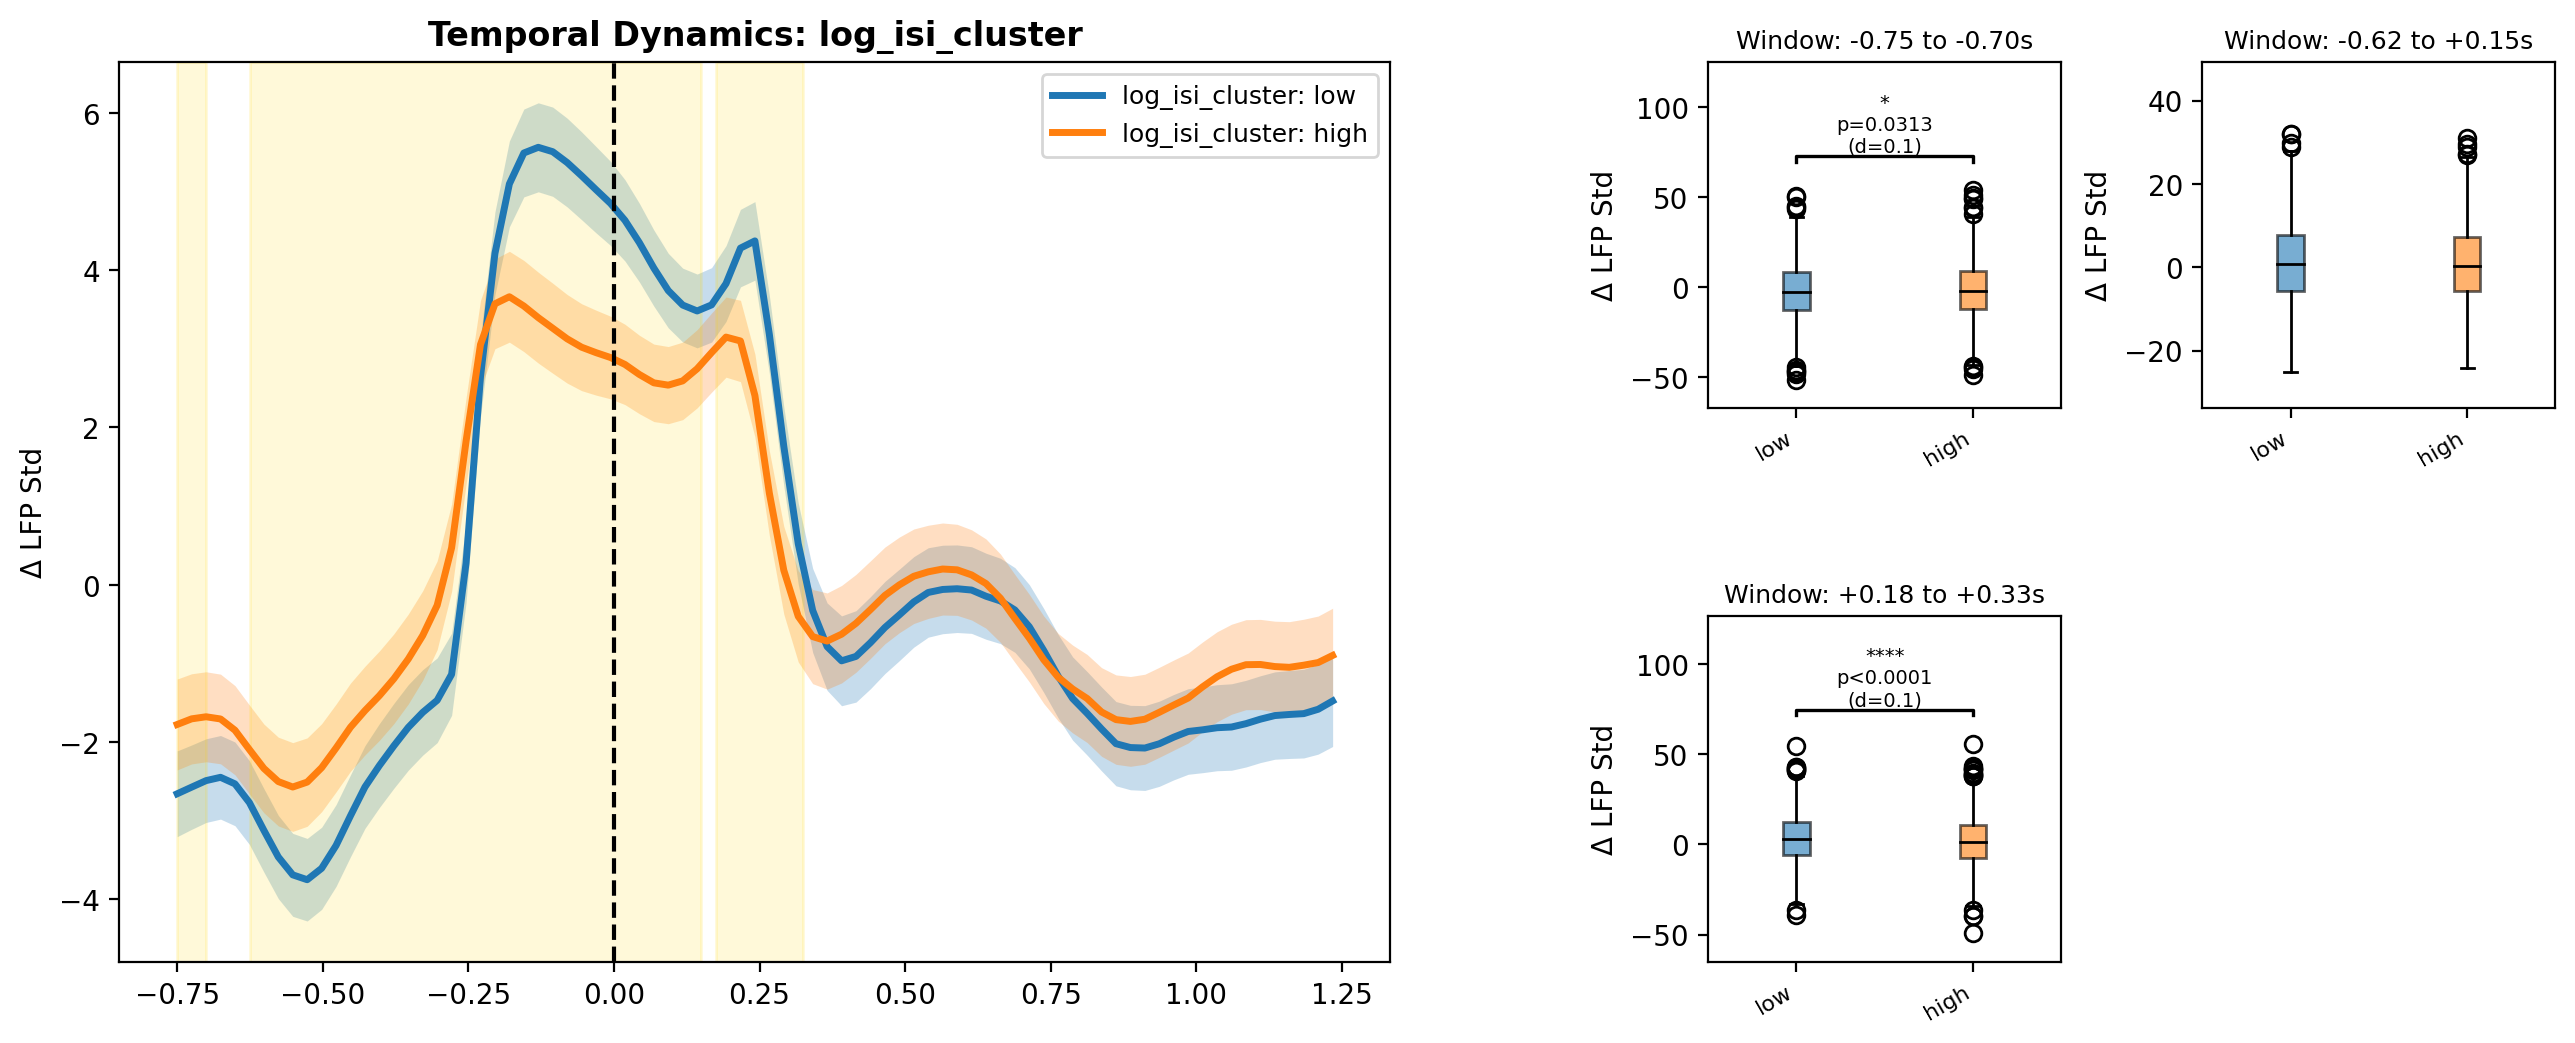


  RUNNING PIPELINE FOR: LFP SPECTRAL EXPONENT



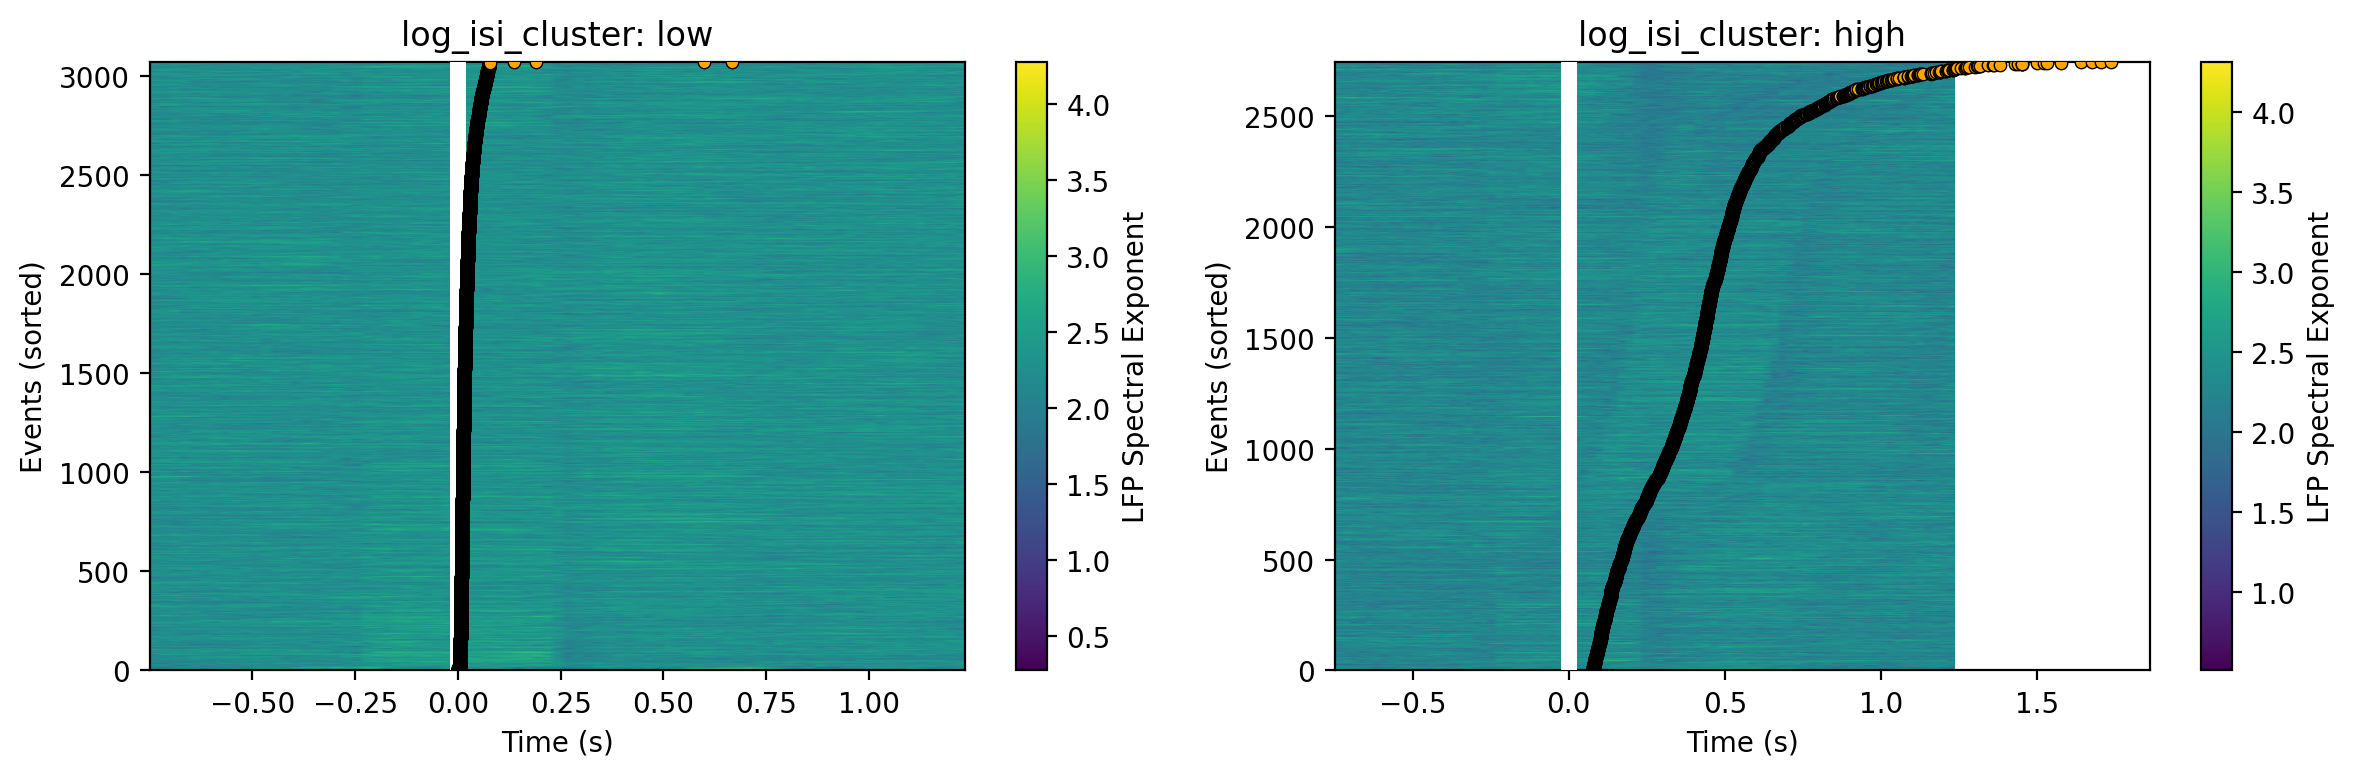

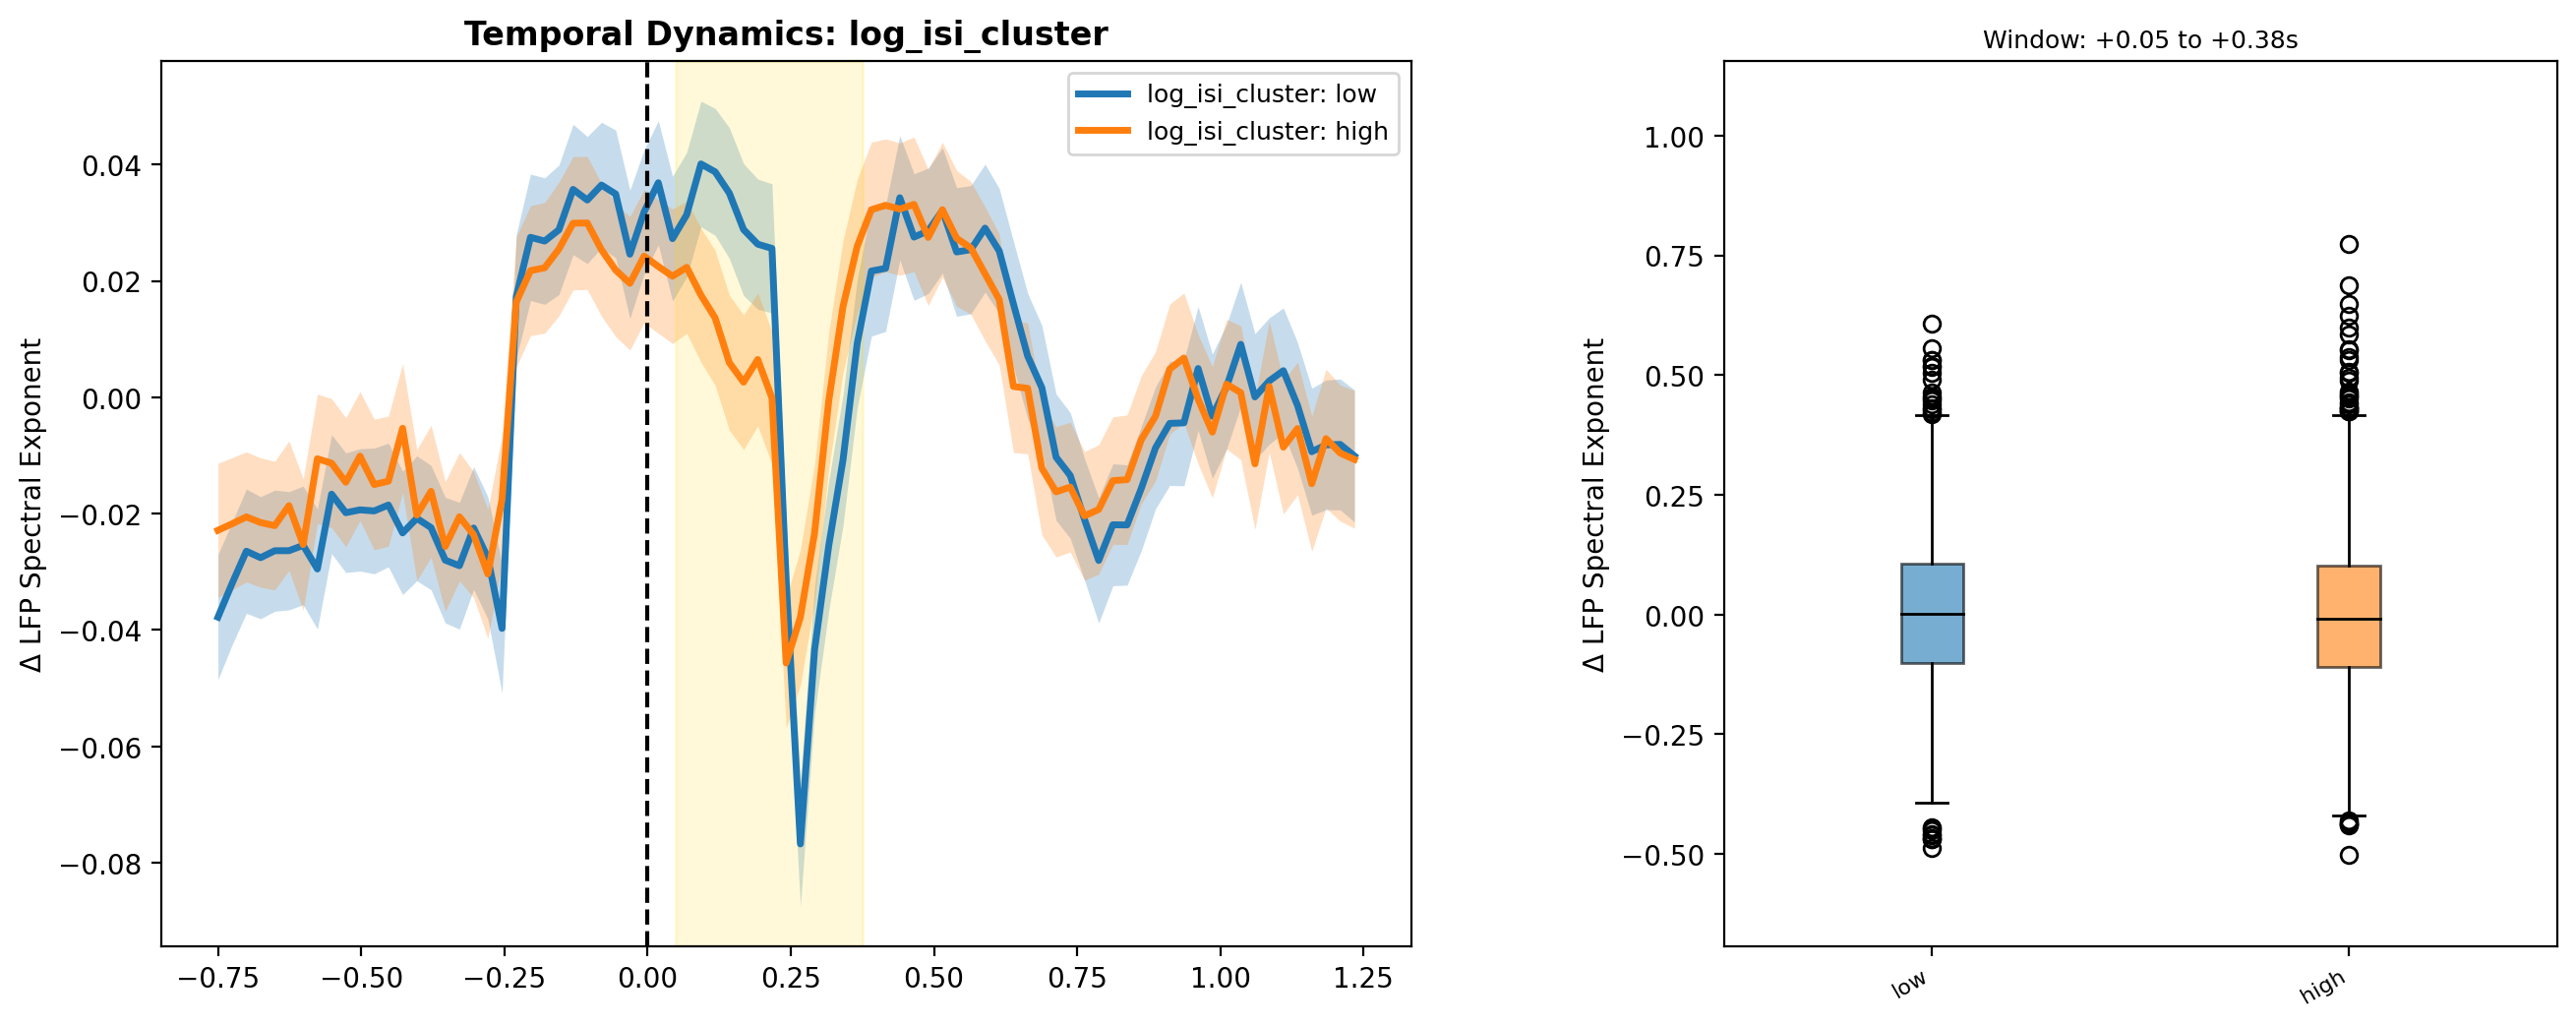


  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/26_sliding_stats.pkl
  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/26_per_spike_data.pkl


In [11]:
features_list = [
    {"feature": "exponent",     "label": "Aperiodic Exponent"},
    {"feature": "offset",       "label": "Aperiodic Offset"},
    {"feature": "band",  "band": "theta",  "label": "Theta AUC"},
    {"feature": "band",  "band": "beta",   "label": "Beta AUC"},
    {"feature": "band",  "band": "gamma",  "label": "Gamma AUC"},
    {"feature": "r_squared",    "label": "r-squared"},
    {"feature": "lfp_mean",     "label": "LFP Mean Amplitude"},
    {"feature": "lfp_std",      "label": "LFP Std"},
    {"feature": "lfp_exponent", "label": "LFP Spectral Exponent"},
]

master_results = run_master_LFP_spk_analysis(
    cell_id=str(cell_num),
    specparam_by_spike=specparam_by_spike,
    groups=groups,
    features_to_analyze=features_list,
    lfp_windows_by_spike=lfp_windows_by_spike,
    window_width=0.05,
    step_size=0.025,
    p_threshold=0.05,
    force_recompute=FORCE_STATS,
    plot=True,
)


## Plot significant windows

In [12]:
plot_significant_windows_spectra(df_features_clust, specparam_by_spike, master_results)



Extacting log_isi_cluster at significant window: -0.575s to -0.475s
  -> Failed to extract valid spectra at t=-0.5249601692880768s

Extacting log_isi_cluster at significant window: -0.400s to -0.075s
  -> Failed to extract valid spectra at t=-0.23746016928807653s

Extacting log_isi_cluster at significant window: 0.025s to 0.400s
  -> Failed to extract valid spectra at t=0.21253983071192387s

Extacting log_isi_cluster at significant window: 0.500s to 0.575s
  -> Failed to extract valid spectra at t=0.5375398307119242s

Extacting log_isi_cluster at significant window: -0.750s to -0.700s
  -> Failed to extract valid spectra at t=-0.7249601692880769s

Extacting log_isi_cluster at significant window: 0.175s to 0.325s
  -> Failed to extract valid spectra at t=0.2500398307119238s
